In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from joblib import dump



In [8]:
df = pd.read_csv('gld_price_data.csv')
df.dropna(inplace=True)

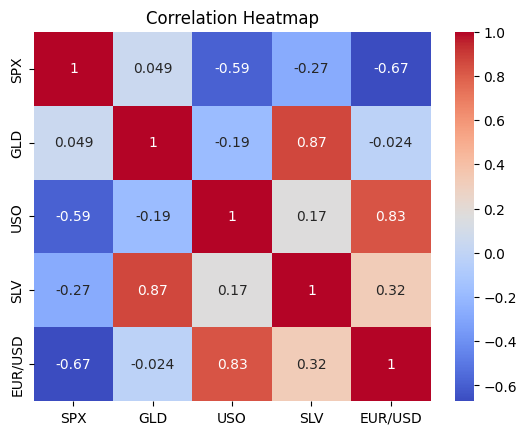

In [9]:
# Only include numeric columns for correlation
numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


In [10]:
features = ['SPX', 'GLD', 'USO', 'SLV', 'EUR/USD']
target = 'GLD'
X = df[features].drop(columns=['GLD'])
y = df['GLD']

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [12]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
df['Cluster'] = clusters

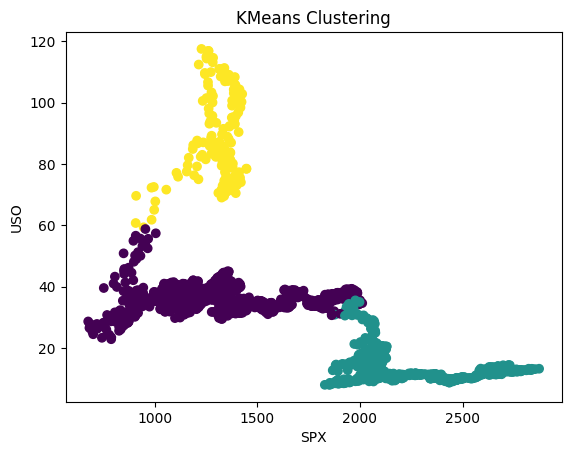

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Select features for clustering
X = df[['SPX', 'USO', 'SLV', 'EUR/USD']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to DataFrame
df['Cluster'] = clusters

# Visualize clusters
plt.scatter(df['SPX'], df['USO'], c=clusters, cmap='viridis')
plt.xlabel('SPX')
plt.ylabel('USO')
plt.title('KMeans Clustering')
plt.show()


In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [16]:
y_pred = model.predict(X_test)
print("MSE:", mean_squared_error(y_test, y_pred))
print("R^2 Score:", r2_score(y_test, y_pred))

MSE: 56.165594215006024
R^2 Score: 0.8975640982991402


In [18]:
dump(model, 'gold_price_model.pkl')

['gold_price_model.pkl']